# Practice Using Diabetes Patient Data

The Diabetes dataset contains data from a total of 442 diabetes patients.
It includes age, sex, body mass index, average blood pressure, and six serum measurements.
This dataset represents examination results from 442 diabetes patients.

Target data: The disease progression measured one year after baseline

Feature data: (All feature data in this dataset are normalized values)

  - Age
  - Sex
  - Body mass index
  - Average blood pressure
  - S1
  - S2
  - S3
  - S4
  - S5
  - S6


In [2]:
import matplotlib.pylab as plt
%matplotlib inline
import pandas as pd
import numpy as np

---
load `diabetes` data

In [3]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

---
print size of your data and target

In [4]:
print(diabetes.data.shape)  # feature matrix shape
print(diabetes.target.shape)  # target vector shape

(442, 10)
(442,)


---
print feature names

In [5]:
diabetes.feature_names # column names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

---
What do s1, s2 and s6 represent?

In [6]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [7]:
X = diabetes.data
y = diabetes.target





### Linear Regression Model

---
Separate train and test data using 80:20 ratio


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=0)

---

- Create a regression model
- Check the R² value of the created regression model. (train score and test score)

In [9]:
# TODO
# 1. Set up the model
# 2. Use fit
# 3. Check the score

In [10]:
from sklearn.linear_model import LinearRegression

# 1. Set up the model
model = LinearRegression()
# 2. Use fit
model.fit(X_train, y_train)
# 3. Check the score
model.score(X_test, y_test)

0.33223321731061817

---
What is the coefficient and intercept?

In [11]:
print(model.coef_)  # Get the coefficients
print("")
print(model.intercept_)  # Get the intercept

[ -35.55025079 -243.16508959  562.76234744  305.46348218 -662.70290089
  324.20738537   24.74879489  170.3249615   731.63743545   43.0309307 ]

152.5380470138517


In [12]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

---
Let's use the model we trained to predict the outcomes for the test dataset.

In [13]:
X_test[0]

array([ 0.01991321,  0.05068012,  0.10480869,  0.0700723 , -0.03596778,
       -0.0266789 , -0.02499266, -0.00259226,  0.00370906,  0.04034337])

In [14]:
sample = np.arange(1, 101).reshape(-1, 10)

model.predict(sample)  # Predict unkown data

array([  9723.41587803,  21930.98684045,  34138.55780287,  46346.12876529,
        58553.69972771,  70761.27069013,  82968.84165255,  95176.41261497,
       107383.98357739, 119591.55453981])

---
What is rmse?

In [15]:
from sklearn.metrics import root_mean_squared_error

y_true = y_test
y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_true, y_pred,)

print("MSE = ", rmse**2, "\tRMSE = ", rmse)

MSE =  3424.259334298693 	RMSE =  58.517171277315626


---

Visualize the test data and the model's predictions using a graph.

If the model performs well, the predicted values will align closely with the 45-degree diagonal line.

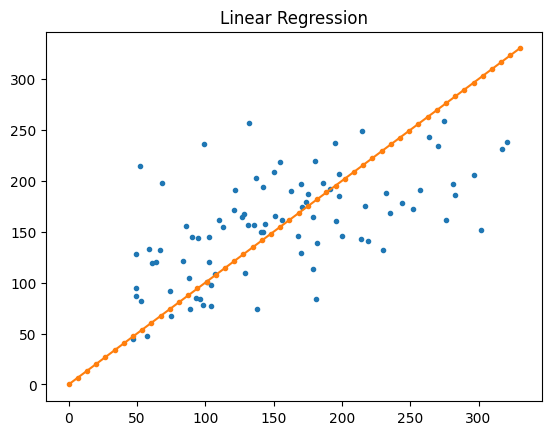

In [16]:
# plot prediction and actual data
plt.plot(y_test, y_pred, '.')

# plot a line, a perfit predict would all fall on this line
x = np.linspace(0, 330, 50)
y = x
plt.plot(x, y, '.-')

plt.title("Linear Regression")
# plt.text("Hello", (5, 5))
plt.show()

In [18]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

# Single Linear Regression

In [39]:
X = diabetes.data[:, 2]
y = diabetes.target

In [41]:
X.shape, y.shape

((442,), (442,))

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
model2 = LinearRegression()

model2.fit(X_train.reshape(-1, 1), y_train)

model2.score(X_test, y_test)

ValueError: Expected 2D array, got 1D array instead:
array=[-0.07626374 -0.06332999 -0.03530688  0.08864151 -0.03638469  0.06385183
  0.09295276 -0.03099563  0.06061839  0.04552903  0.06924089 -0.0105172
  0.11019775  0.01211685 -0.02452876 -0.01806189 -0.04069594  0.05522933
 -0.02560657  0.00241654 -0.0374625   0.00457217  0.03043966 -0.02345095
 -0.03961813 -0.03422907  0.04552903  0.02073935 -0.05794093 -0.04069594
  0.02828403 -0.02884001  0.04984027  0.02828403  0.00457217 -0.046085
 -0.00836158  0.0347509  -0.046085    0.05630715 -0.06656343  0.04768465
  0.06169621 -0.00836158  0.03367309  0.03043966  0.00672779 -0.02237314
  0.00457217 -0.06009656 -0.04716281  0.03043966 -0.00620595 -0.03961813
  0.02397278 -0.00620595 -0.02560657  0.11127556 -0.03961813  0.08540807
 -0.03530688 -0.0191397  -0.06548562 -0.06656343 -0.03638469 -0.00512814
 -0.03099563  0.00564998  0.097264    0.03798434 -0.04069594 -0.06979687
 -0.00728377  0.02720622 -0.00081689 -0.05255187 -0.046085   -0.0256